In [1]:
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
# Load data
folder_path_cold = "../results/multishot_cold/trustgame/"
folder_path_ir = "../results/multishot_ir/trustgame/"

def load_data(folder_path):
    data = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(".json"):
                file_path = os.path.join(root, filename)
                try:
                    with open(file_path, "r") as f:
                        entry = json.load(f)
                        data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Skipped invalid JSON: {file_path} ({e})")
    
    print(f"Loaded {len(data)} valid JSON result files from '{folder_path}' and its subfolders.")
    return data

data_cold = load_data(folder_path_cold)
data_ir = load_data(folder_path_ir)

Loaded 474 valid JSON result files from '../results/multishot_cold/trustgame/' and its subfolders.
Loaded 394 valid JSON result files from '../results/multishot_ir/trustgame/' and its subfolders.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

def process_by_round(data):
    # Set constants
    base_amount = 100
    multiplier = 3
    
    # Dictionary to store results by round: {round_num: {give_data: [], return_data: []}}
    rounds_data = defaultdict(lambda: {"give_data": [], "return_pct_data": []})
    
    # Aggregate data by round
    for entry in data:
        m0 = entry["model_general_name_0"]
        m1 = entry["model_general_name_1"]
        
        # Process each run in the game history
        game_history = entry.get("game_history", {})
        for run_key, run_data in game_history.items():
            if run_data:  # Skip empty runs
                # Extract round number from run_key (e.g., "run_1" -> 1)
                round_num = int(run_key.split("_")[1])
                
                sent = int(run_data["agent_0_answer"]["amount"])
                received_back = int(run_data["agent_1_answer"]["amount"])
                sent_back_pct = received_back / (sent * multiplier) if sent > 0 else 0.0
                
                rounds_data[round_num]["give_data"].append({
                    "sender": m0,
                    "receiver": m1,
                    "sent_amount": sent
                })
                
                rounds_data[round_num]["return_pct_data"].append({
                    "sender": m1,     # agent_1 is now sender in return
                    "receiver": m0,
                    "return_pct": sent_back_pct * 100  # percentage
                })
    
    # Convert to heatmaps by round
    round_heatmaps = {}
    for round_num in sorted(rounds_data.keys()):
        df_give = pd.DataFrame(rounds_data[round_num]["give_data"])
        df_return = pd.DataFrame(rounds_data[round_num]["return_pct_data"])
        
        # Pivot into heatmap format
        heatmap_give = df_give.pivot_table(index="sender", columns="receiver", values="sent_amount", aggfunc="mean")
        heatmap_return = df_return.pivot_table(index="sender", columns="receiver", values="return_pct", aggfunc="mean")
        
        round_heatmaps[round_num] = {
            "heatmap_give": heatmap_give,
            "heatmap_return": heatmap_return
        }
    
    return round_heatmaps

rounds_cold = process_by_round(data_cold)
rounds_ir = process_by_round(data_ir)

print("Available rounds in cold data:", sorted(rounds_cold.keys()))
print("Available rounds in IR data:", sorted(rounds_ir.keys()))

Available rounds in cold data: [1, 2, 3, 4, 5]
Available rounds in IR data: [1, 2, 3, 4, 5]


In [4]:
def plot_results_trustor_by_round(round_heatmaps, condition_name):
    """Plot trustor (amount sent) results for each round"""
    rounds = sorted(round_heatmaps.keys())
    n_rounds = len(rounds)
    
    fig, axes = plt.subplots(1, n_rounds, figsize=(6*n_rounds, 5))
    if n_rounds == 1:
        axes = [axes]
    
    for i, round_num in enumerate(rounds):
        heatmap_give = round_heatmaps[round_num]["heatmap_give"]
        
        sns.heatmap(heatmap_give, annot=True, fmt=".1f", cmap="YlGnBu", 
                   cbar_kws={'label': 'Amount Sent'} if i == n_rounds-1 else None,
                   vmin=0, vmax=100, ax=axes[i], 
                   cbar=i == n_rounds-1)
        axes[i].set_title(f"Round {round_num}")
        axes[i].set_ylabel("Trustor (Sender)" if i == 0 else "")
        axes[i].set_xlabel("Trustee (Receiver)")
    
    plt.suptitle(f"Trust Game – Trustor - Trustor Sent % Amount to Trustee ({condition_name})", fontsize=16)
    plt.tight_layout()
    plt.show()

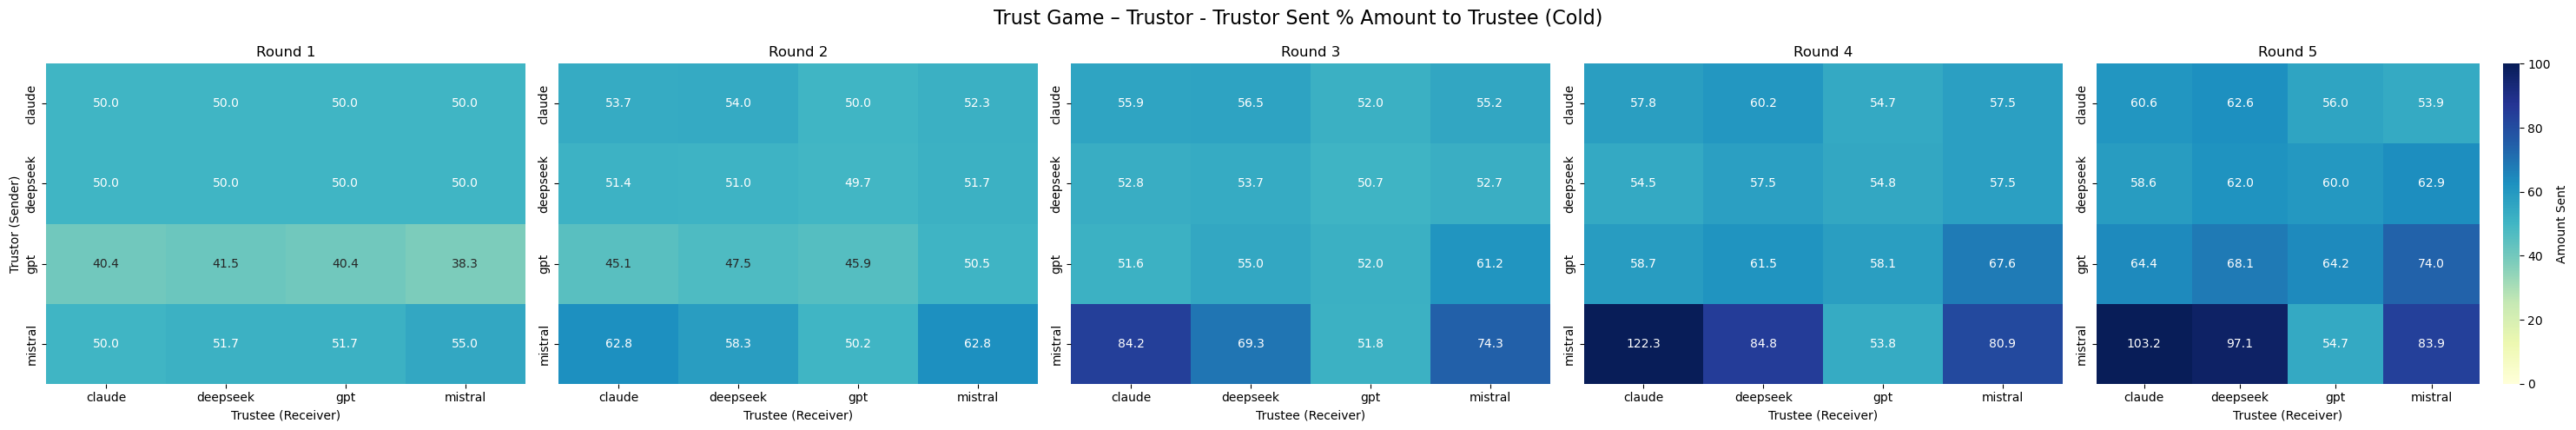

In [5]:
plot_results_trustor_by_round(rounds_cold, "Cold")

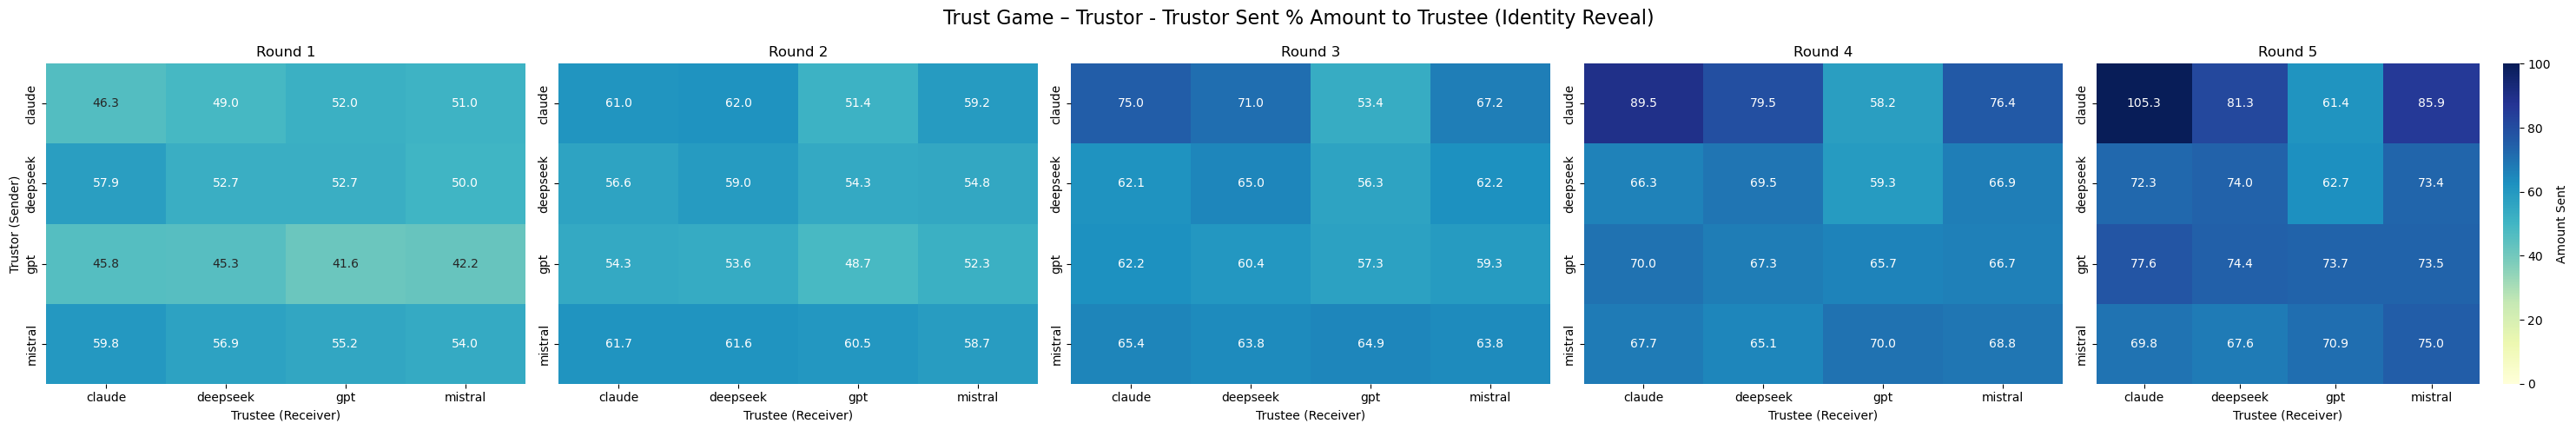

In [6]:
plot_results_trustor_by_round(rounds_ir, "Identity Reveal")

In [7]:
# Plot Heatmap 2 – Return Percentage (agent_1 → agent_0)
def plot_results_trustee_by_round(round_heatmaps, condition_name):
    """Plot trustee (return percentage) results for each round"""
    rounds = sorted(round_heatmaps.keys())
    n_rounds = len(rounds)
    
    fig, axes = plt.subplots(1, n_rounds, figsize=(6*n_rounds, 5))
    if n_rounds == 1:
        axes = [axes]
    
    for i, round_num in enumerate(rounds):
        heatmap_return = round_heatmaps[round_num]["heatmap_return"]
        
        sns.heatmap(heatmap_return, annot=True, fmt=".1f", cmap="YlGnBu", 
                   cbar_kws={'label': '% Returned'} if i == n_rounds-1 else None,
                   vmin=0, vmax=100, ax=axes[i],
                   cbar=i == n_rounds-1)
        axes[i].set_title(f"Round {round_num}")
        axes[i].set_ylabel("Trustee (Sender)" if i == 0 else "")
        axes[i].set_xlabel("Trustor (Receiver)")
    
    plt.suptitle(f"Trust Game – Trustee - Trustee Returned % of Multiplied Amount ({condition_name})", fontsize=16)
    plt.tight_layout()
    plt.show()

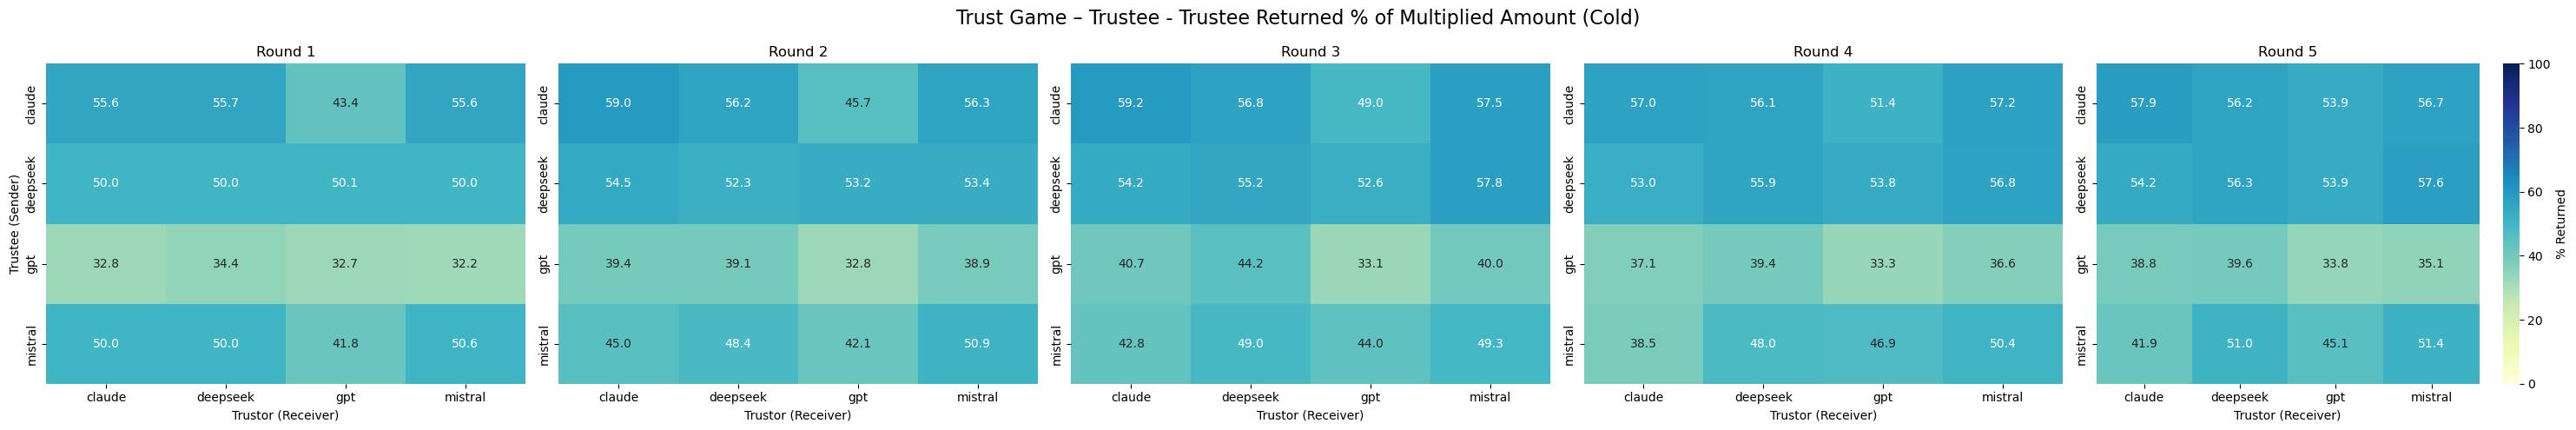

In [8]:
plot_results_trustee_by_round(rounds_cold, "Cold")

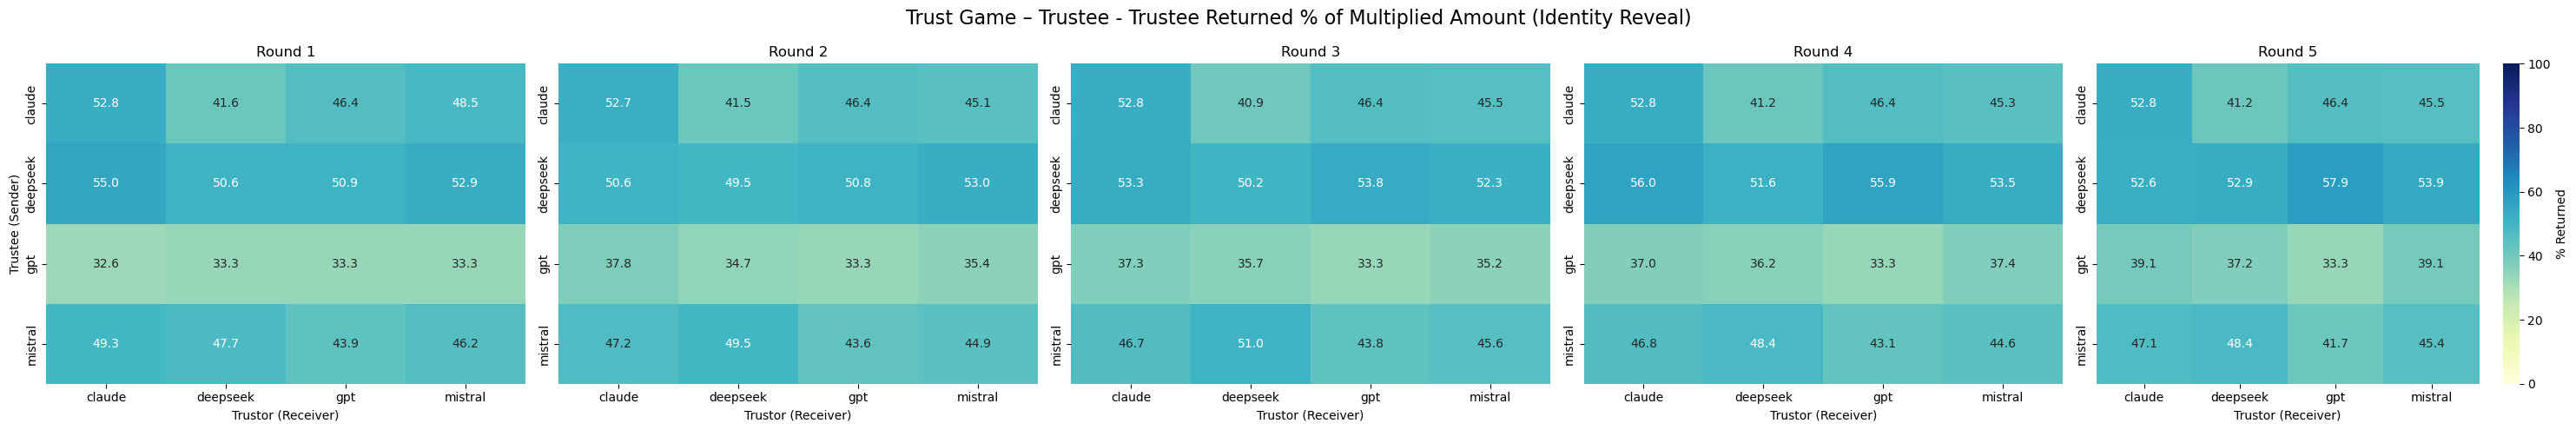

In [9]:
plot_results_trustee_by_round(rounds_ir, "Identity Reveal")